# **COVID-19, Pneumonia, and Normal Chest X-ray Classification Using Deep Learning**

## Introduction

Chest X-ray imaging plays an important role in diagnosing respiratory diseases such as COVID-19 and Pneumonia. Manual interpretation of X-ray images requires experienced radiologists and may be time-consuming. Deep learning techniques can assist healthcare professionals by automatically classifying chest X-ray images.

This project aims to develop and compare multiple deep learning models for classifying chest X-ray images into three categories: COVID-19, Normal, and Pneumonia.

## Objectives

- To develop an automated chest X-ray classification system.
- To classify X-ray images into COVID-19, Pneumonia, and Normal categories.
- To compare the performance of Custom CNN, VGG16, ResNet50, and EfficientNetB0 models.
- To identify the best-performing model using evaluation metrics.

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, GlobalAveragePooling2D,
    BatchNormalization, Conv2D, MaxPool2D
)
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import gradio as gr

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
print("All imports done!")

All imports done!


In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# **Step 1: Import Dataset**

## Dataset Description

The dataset contains chest X-ray images belonging to three balanced classes:
- COVID-19 — 2313 images
- Normal — 2313 images
- Pneumonia — 2313 images

Total: 6939 images. Image size used: 224 × 224 pixels.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset")
print("Path:", path)

Using Colab cache for faster access to the 'covid19-pneumonia-normal-chest-xray-pa-dataset' dataset.
Path: /kaggle/input/covid19-pneumonia-normal-chest-xray-pa-dataset


In [ ]:
dataset_path = path
CLASSES  = ['covid', 'normal', 'pneumonia']
IMG_SIZE = 128
BATCH    = 32
COLORS   = ['#e74c3c', '#2ecc71', '#3498db']

# Verify folders exist
for cls in CLASSES:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f"{cls}: {count} images")

covid: 2313 images
normal: 2313 images
pneumonia: 2313 images


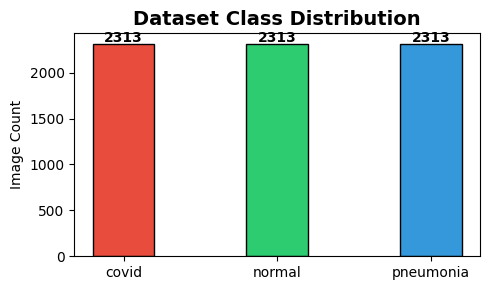

In [ ]:
train_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in CLASSES}

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(train_counts.keys(), train_counts.values(), color=COLORS, edgecolor='black', width=0.4)
ax.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Image Count')
for i, (k, v) in enumerate(train_counts.items()):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

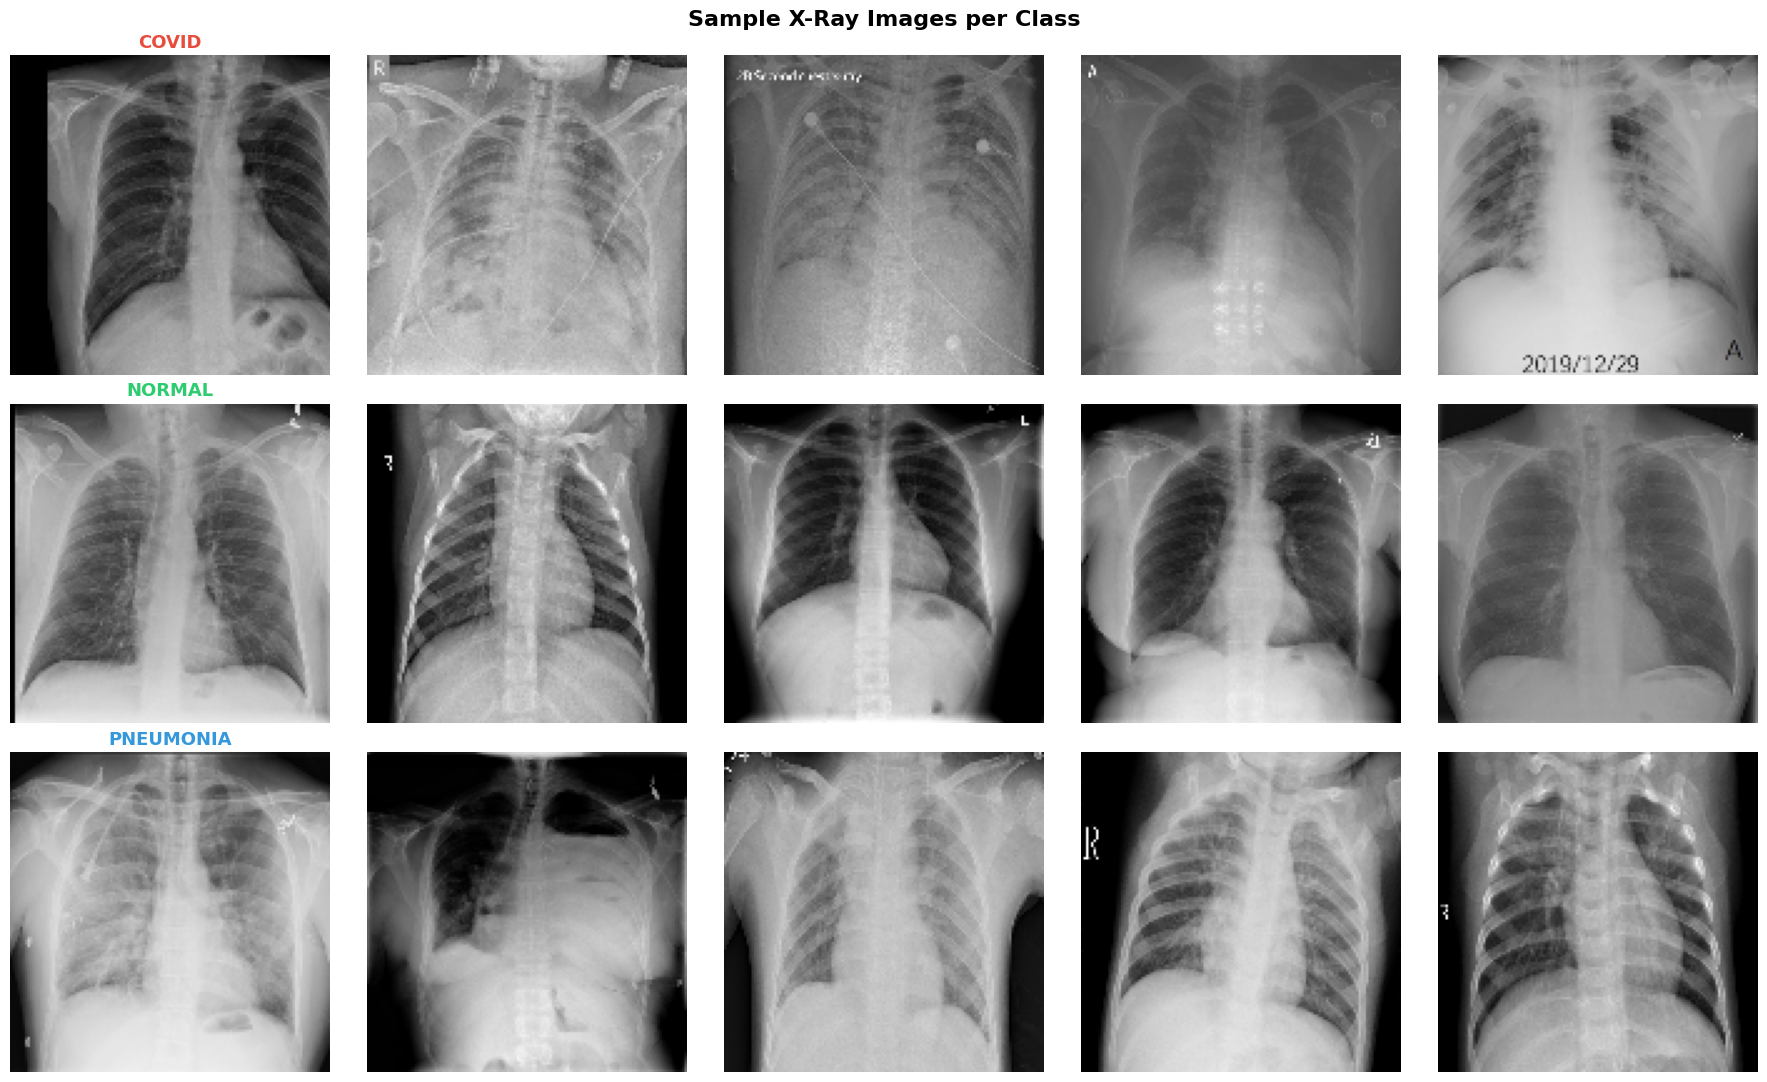

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(dataset_path, cls)
    images = random.sample(os.listdir(cls_path), 5)
    for col, img_name in enumerate(images):
        img = cv2.imread(os.path.join(cls_path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls.upper(), fontsize=13, fontweight='bold', color=COLORS[row])
plt.suptitle('Sample X-Ray Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()

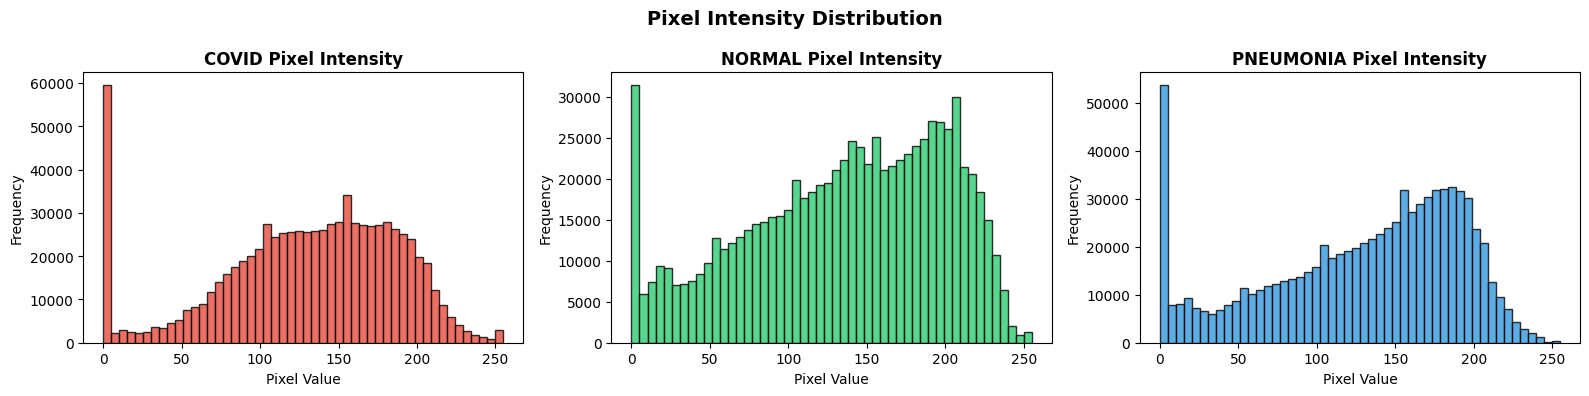

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, cls in enumerate(CLASSES):
    cls_path = os.path.join(dataset_path, cls)
    sample_imgs = random.sample(os.listdir(cls_path), 50)
    pixels = []
    for img_name in sample_imgs:
        img = cv2.imread(os.path.join(cls_path, img_name), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        pixels.extend(img.flatten().tolist())
    axes[idx].hist(pixels, bins=50, color=COLORS[idx], alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{cls.upper()} Pixel Intensity', fontweight='bold')
    axes[idx].set_xlabel('Pixel Value')
    axes[idx].set_ylabel('Frequency')
plt.suptitle('Pixel Intensity Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_intensity.png', dpi=100)
plt.show()

# **Step 2: Data Preprocessing and Dataset Splitting**

**Key fixes applied:**
- `horizontal_flip=False` — X-rays must NOT be flipped (left/right lung anatomy matters)
- Each model gets its own correct preprocessing function (VGG16, ResNet50, EfficientNet each need different normalization)
- Mild augmentation only — heavy augmentation destroys X-ray patterns
- 80% training / 20% validation split

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

def make_generators(preprocess_fn=None):
    if preprocess_fn:
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            rotation_range=10,
            zoom_range=0.1,
            width_shift_range=0.1,
            height_shift_range=0.1,
            horizontal_flip=False,
            fill_mode='nearest',
            validation_split=0.2
        )
        val_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            validation_split=0.2
        )
    else:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            zoom_range=0.1,
            width_shift_range=0.1,
            height_shift_range=0.1,
            horizontal_flip=False,
            fill_mode='nearest',
            validation_split=0.2
        )
        val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

    train_gen = train_datagen.flow_from_directory(
        dataset_path, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH, class_mode='categorical',
        subset='training', shuffle=True, seed=42
    )
    val_gen = val_datagen.flow_from_directory(
        dataset_path, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH, class_mode='categorical',
        subset='validation', shuffle=False, seed=42
    )
    return train_gen, val_gen

import multiprocessing
workers = multiprocessing.cpu_count()
print(f"Using {workers} workers for data loading")

# Each model gets its own correctly preprocessed generators
cnn_train,     cnn_val     = make_generators(preprocess_fn=None)
vgg_train,     vgg_val     = make_generators(preprocess_fn=vgg_preprocess)
resnet_train,  resnet_val  = make_generators(preprocess_fn=resnet_preprocess)
eff_train,     eff_val     = make_generators(preprocess_fn=eff_preprocess)

print("Generators ready!")

Using 2 workers for data loading
Found 5523 images belonging to 3 classes.
Found 1379 images belonging to 3 classes.
Found 5523 images belonging to 3 classes.
Found 1379 images belonging to 3 classes.
Found 5523 images belonging to 3 classes.
Found 1379 images belonging to 3 classes.
Found 5523 images belonging to 3 classes.
Found 1379 images belonging to 3 classes.
Generators ready!


In [ ]:
# Shared class weights (dataset is balanced, so weights will all be ~1.0,
# but keeping this is good practice)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=cnn_train.classes
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

def get_callbacks(model_name):
    return [
        ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=7,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

Class weights: {0: np.float64(1.0109829763866007), 1: np.float64(0.9945975148568341), 2: np.float64(0.9945975148568341)}


# **Step 3: Model Development**

## Model 1: Custom CNN

**Fixes applied:**
- Added a 5th conv block (512 filters) for more feature depth
- Reduced dropout slightly to 0.5 to avoid under-learning
- Added L2 regularization to conv layers to prevent overfitting
- Learning rate starts at 1e-3 and decays via callback

In [ ]:
from tensorflow.keras.regularizers import l2

def build_custom_cnn():
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same',
               kernel_regularizer=l2(1e-4), input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Dropout(0.3),

        # Block 4
        Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Dropout(0.3),

        # Block 5
        Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPool2D(2, 2),

        GlobalAveragePooling2D(),
        Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax', dtype='float32')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()
    return model

cnn_model = build_custom_cnn()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,097,955 (8.00 MB)

 Trainable params: 2,094,499 (7.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [ ]:
print("Training Custom CNN...")
cnn_history = cnn_model.fit(
    cnn_train,
    epochs=10,
    validation_data=cnn_val,
    callbacks=get_callbacks('cnn'),
    class_weight=class_weight_dict,
    verbose=1
)
print("Custom CNN done!")

Training Custom CNN...
Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.7230 - loss: 0.9020 - val_accuracy: 0.3350 - val_loss: 9.7773 - learning_rate: 0.0010
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 104s 601ms/step - accuracy: 0.8591 - loss: 0.5376 - val_accuracy: 0.3691 - val_loss: 2.1630 - learning_rate: 0.0010
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 104s 601ms/step - accuracy: 0.8756 - loss: 0.4789 - val_accuracy: 0.5424 - val_loss: 2.2889 - learning_rate: 0.0010
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 108s 619ms/step - accuracy: 0.9080 - loss: 0.4018 - val_accuracy: 0.3299 - val_loss: 9.3657 - learning_rate: 0.0010
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9167 - loss: 0.3854
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
173/173 ━━━━━━━━━━━━━━━━━━━━ 101s 586ms/step - accuracy: 0.9176 - loss: 0.3794 - val_accuracy: 0.4728 - val_loss: 2.7787 - learning_rate: 0.0010
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 100s 58

Custom CNN — Per Class Accuracy:
  COVID       : 98.02%
  NORMAL      : 86.36%
  PNEUMONIA   : 57.79%

  Overall Acc : 80.73%

Detailed Report:
              precision    recall  f1-score   support

       covid       0.82      0.98      0.90       455
      normal       0.70      0.86      0.77       462
   pneumonia       0.99      0.58      0.73       462

    accuracy                           0.81      1379
   macro avg       0.84      0.81      0.80      1379
weighted avg       0.84      0.81      0.80      1379



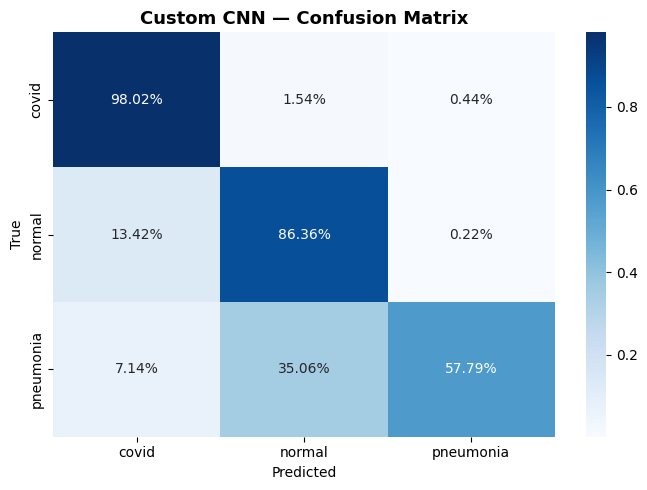

In [ ]:
# Reset and predict
cnn_val.reset()
cnn_preds = cnn_model.predict(cnn_val, verbose=0)
cnn_pred_classes = np.argmax(cnn_preds, axis=1)
cnn_true_classes = cnn_val.classes

# Per-class accuracy
cm = confusion_matrix(cnn_true_classes, cnn_pred_classes)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("Custom CNN — Per Class Accuracy:")
print("=" * 35)
for cls, acc in zip(CLASSES, per_class_acc):
    print(f"  {cls.upper():<12}: {acc:.2f}%")
print(f"\n  Overall Acc : {np.mean(per_class_acc):.2f}%")
print("=" * 35)

# Full classification report
print("\nDetailed Report:")
print(classification_report(cnn_true_classes, cnn_pred_classes, target_names=CLASSES))

# Confusion matrix heatmap
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Custom CNN — Confusion Matrix', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

## Model 2: VGG16 Transfer Learning

**Bug fixed:** The original code had the classifier head INSIDE the `for` loop — this was a critical indentation bug that caused the model to be built incorrectly every iteration.

**Improvements:**
- Fixed indentation bug (head is now outside the loop)
- Unfreezing last 8 layers for fine-tuning
- Lower LR (1e-4) appropriate for fine-tuning

In [ ]:
def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Freeze all layers except the last 8 (last 2 conv blocks)
    for layer in base.layers[:-8]:
        layer.trainable = False
    for layer in base.layers[-8:]:
        layer.trainable = True

    # FIX: classifier head is OUTSIDE the loop (was a critical indentation bug)
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    out = Dense(3, activation='softmax')(x)

    model = Model(base.input, out)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

vgg_model = build_vgg16()
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           77

 Total params: 14,847,811 (56.64 MB)

 Trainable params: 13,111,811 (50.02 MB)

 Non-trainable params: 1,736,000 (6.62 MB)

In [ ]:
class_weight_dict = {
    0: 1.0,   # covid
    1: 1.0,   # normal
    2: 2.0    # pneumonia — double weight
}

In [ ]:
print("Training VGG16...")
vgg_history = vgg_model.fit(
    vgg_train,
    epochs=8,
    validation_data=vgg_val,
    callbacks=get_callbacks('vgg16'),
    class_weight=class_weight_dict,
    verbose=1
)
print("VGG16 done!")

Training VGG16...
Epoch 1/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 139s 709ms/step - accuracy: 0.8687 - loss: 0.4299 - val_accuracy: 0.7926 - val_loss: 1.4521 - learning_rate: 1.0000e-04
Epoch 2/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 103s 590ms/step - accuracy: 0.9352 - loss: 0.2078 - val_accuracy: 0.7063 - val_loss: 2.5488 - learning_rate: 1.0000e-04
Epoch 3/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 103s 594ms/step - accuracy: 0.9598 - loss: 0.1375 - val_accuracy: 0.8281 - val_loss: 1.3281 - learning_rate: 1.0000e-04
Epoch 4/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 101s 581ms/step - accuracy: 0.9705 - loss: 0.1123 - val_accuracy: 0.6396 - val_loss: 2.4427 - learning_rate: 1.0000e-04
Epoch 5/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 103s 593ms/step - accuracy: 0.9739 - loss: 0.0935 - val_accuracy: 0.8006 - val_loss: 1.2322 - learning_rate: 1.0000e-04
Epoch 6/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 103s 596ms/step - accuracy: 0.9774 - loss: 0.0855 - val_accuracy: 0.7600 - val_loss: 2.2845 - learning_rate: 1.0000e-04
Epoch 7/8
173/173 ━━━━━━━━━━

In [ ]:
# Check VGG16 per class accuracy
vgg_val.reset()
vgg_preds = vgg_model.predict(vgg_val, verbose=0)
vgg_pred_classes = np.argmax(vgg_preds, axis=1)
vgg_true_classes = vgg_val.classes

cm = confusion_matrix(vgg_true_classes, vgg_pred_classes)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("VGG16 — Per Class Accuracy:")
print("=" * 35)
for cls, acc in zip(CLASSES, per_class_acc):
    print(f"  {cls.upper():<12}: {acc:.2f}%")
print(f"\n  Overall Acc : {np.mean(per_class_acc):.2f}%")
print("=" * 35)

print("\nDetailed Report:")
print(classification_report(vgg_true_classes, vgg_pred_classes, target_names=CLASSES))

VGG16 — Per Class Accuracy:
  COVID       : 97.14%
  NORMAL      : 91.34%
  PNEUMONIA   : 60.17%

  Overall Acc : 82.89%

Detailed Report:
              precision    recall  f1-score   support

       covid       0.86      0.97      0.92       455
      normal       0.72      0.91      0.80       462
   pneumonia       1.00      0.60      0.75       462

    accuracy                           0.83      1379
   macro avg       0.86      0.83      0.82      1379
weighted avg       0.86      0.83      0.82      1379



## Model 3: ResNet50 Transfer Learning

**Improvements:**
- BatchNorm layers kept frozen (critical for ResNet — unfreezing BN causes instability)
- Lower LR (5e-5) since ResNet is sensitive to gradient updates
- Unfreezing last 30 layers for deep fine-tuning

In [ ]:
def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))

    base.trainable = True
    for layer in base.layers[:-40]:    # unfreeze more layers than before
        layer.trainable = False

    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)   # bigger dense layer
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)   # extra dense layer
    x = Dropout(0.3)(x)
    out = Dense(3, activation='softmax')(x)

    model = Model(base.input, out)
    model.compile(
        optimizer=Adam(learning_rate=3e-5),  # lower LR for stability
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

resnet_model = build_resnet50()
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,770,947 (94.49 MB)

 Trainable params: 16,988,931 (64.81 MB)

 Non-trainable params: 7,782,016 (29.69 MB)

In [ ]:
print("Training ResNet50...")
class_weight_dict = {
    0: 1.0,   # covid
    1: 1.0,   # normal
    2: 3.0    # pneumonia — triple weight
}

resnet_history = resnet_model.fit(
    resnet_train,
    epochs=15,
    validation_data=resnet_val,
    callbacks=get_callbacks('resnet50'),
    class_weight=class_weight_dict,
    verbose=1
)
print("ResNet50 done!")
print("ResNet50 done!")

Training ResNet50...
Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 170s 789ms/step - accuracy: 0.7987 - loss: 0.6583 - val_accuracy: 0.7389 - val_loss: 1.6191 - learning_rate: 3.0000e-05
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 106s 610ms/step - accuracy: 0.9258 - loss: 0.2450 - val_accuracy: 0.7890 - val_loss: 1.8048 - learning_rate: 3.0000e-05
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 109s 628ms/step - accuracy: 0.9426 - loss: 0.1992 - val_accuracy: 0.8289 - val_loss: 1.2566 - learning_rate: 3.0000e-05
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 105s 608ms/step - accuracy: 0.9623 - loss: 0.1374 - val_accuracy: 0.7977 - val_loss: 1.5944 - learning_rate: 3.0000e-05
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 105s 605ms/step - accuracy: 0.9614 - loss: 0.1425 - val_accuracy: 0.8245 - val_loss: 0.9805 - learning_rate: 3.0000e-05
Epoch 6/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 106s 610ms/step - accuracy: 0.9640 - loss: 0.1204 - val_accuracy: 0.7977 - val_loss: 1.6435 - learning_rate: 3.0000e-05
Epoch 7/15
173/173 

In [ ]:
resnet_val.reset()
resnet_preds = resnet_model.predict(resnet_val, verbose=0)
resnet_pred_classes = np.argmax(resnet_preds, axis=1)
resnet_true_classes = resnet_val.classes

cm = confusion_matrix(resnet_true_classes, resnet_pred_classes)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("ResNet50 — Per Class Accuracy:")
print("=" * 35)
for cls, acc in zip(CLASSES, per_class_acc):
    print(f"  {cls.upper():<12}: {acc:.2f}%")
print(f"\n  Overall Acc : {np.mean(per_class_acc):.2f}%")
print("=" * 35)

print("\nDetailed Report:")
print(classification_report(resnet_true_classes, resnet_pred_classes, target_names=CLASSES))

ResNet50 — Per Class Accuracy:
  COVID       : 94.51%
  NORMAL      : 97.84%
  PNEUMONIA   : 59.52%

  Overall Acc : 83.95%

Detailed Report:
              precision    recall  f1-score   support

       covid       0.95      0.95      0.95       455
      normal       0.69      0.98      0.81       462
   pneumonia       0.99      0.60      0.74       462

    accuracy                           0.84      1379
   macro avg       0.88      0.84      0.84      1379
weighted avg       0.88      0.84      0.83      1379



In [ ]:
# See exactly where pneumonia is going wrong
cm = confusion_matrix(resnet_true_classes, resnet_pred_classes)
print("Confusion Matrix:")
print(f"{'':12} {'Pred COVID':12} {'Pred NORMAL':12} {'Pred PNEUMONIA':12}")
print(f"{'True COVID':12} {cm[0][0]:<12} {cm[0][1]:<12} {cm[0][2]:<12}")
print(f"{'True NORMAL':12} {cm[1][0]:<12} {cm[1][1]:<12} {cm[1][2]:<12}")
print(f"{'True PNEUMONIA':12} {cm[2][0]:<12} {cm[2][1]:<12} {cm[2][2]:<12}")



Confusion Matrix:
             Pred COVID   Pred NORMAL  Pred PNEUMONIA
True COVID   430          23           2           
True NORMAL  10           452          0           
True PNEUMONIA 11           176          275         


## Model 4: EfficientNetB0 Transfer Learning

**Improvements:**
- BN layers kept frozen (same reason as ResNet)
- Uses its own `eff_preprocess` generator (not the shared one)
- LR 1e-4 with decay via callback

In [ ]:
import tensorflow.keras.backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=1)
    return loss_fn

def build_efficientnet():
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers[:-40]:
        layer.trainable = False
    for layer in base.layers[-40:]:
        layer.trainable = True

    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(3, activation='softmax')(x)

    model = Model(base.input, out)
    model.compile(
        optimizer=Adam(learning_rate=3e-5),
        loss=focal_loss(gamma=2.0, alpha=0.25),  # focal loss instead of crossentropy
        metrics=['accuracy']
    )
    return model

efficientnet_model = build_efficientnet()
efficientnet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 128, 128,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 128, 128,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 128, 128,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 4,839,590 (18.46 MB)

 Trainable params: 2,826,515 (10.78 MB)

 Non-trainable params: 2,013,075 (7.68 MB)

In [ ]:
print("Training EfficientNetB0...")
# Higher pneumonia weight + focal loss together
class_weight_dict = {
    0: 1.0,   # covid
    1: 1.5,   # normal — slightly higher to stop pneumonia→normal confusion
    2: 4.0    # pneumonia — quadruple weight
}

efficientnet_history = efficientnet_model.fit(
    eff_train,
    epochs=15,
    validation_data=eff_val,
    callbacks=get_callbacks('efficientnet'),
    class_weight=class_weight_dict,
    verbose=1
)
print("EfficientNet done!")

Training EfficientNetB0...
Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.6344 - loss: 0.2583 - val_accuracy: 0.6759 - val_loss: 0.1061 - learning_rate: 3.0000e-05
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 102s 589ms/step - accuracy: 0.7887 - loss: 0.1203 - val_accuracy: 0.7353 - val_loss: 0.1380 - learning_rate: 3.0000e-05
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 101s 583ms/step - accuracy: 0.8285 - loss: 0.0864 - val_accuracy: 0.7534 - val_loss: 0.1704 - learning_rate: 3.0000e-05
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8468 - loss: 0.0797
Epoch 4: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
173/173 ━━━━━━━━━━━━━━━━━━━━ 101s 587ms/step - accuracy: 0.8519 - loss: 0.0781 - val_accuracy: 0.7658 - val_loss: 0.1924 - learning_rate: 3.0000e-05
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 101s 584ms/step - accuracy: 0.8631 - loss: 0.0711 - val_accuracy: 0.7679 - val_loss: 0.1947 - learning_rate: 9.0000e-06
Epoch 6/15
173/173 ━━━━

In [ ]:
eff_val.reset()
eff_preds = efficientnet_model.predict(eff_val, verbose=0)
eff_pred_classes = np.argmax(eff_preds, axis=1)
eff_true_classes = eff_val.classes

cm = confusion_matrix(eff_true_classes, eff_pred_classes)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

print("EfficientNet — Per Class Accuracy:")
print("=" * 35)
for cls, acc in zip(CLASSES, per_class_acc):
    print(f"  {cls.upper():<12}: {acc:.2f}%")
print(f"\n  Overall Acc : {np.mean(per_class_acc):.2f}%")
print("=" * 35)

print("\nDetailed Report:")
print(classification_report(eff_true_classes, eff_pred_classes, target_names=CLASSES))

# Confusion matrix to see where pneumonia is going
print("\nConfusion Matrix:")
print(f"{'':12} {'Pred COVID':12} {'Pred NORMAL':12} {'Pred PNEUMONIA':12}")
print(f"{'True COVID':12} {cm[0][0]:<12} {cm[0][1]:<12} {cm[0][2]:<12}")
print(f"{'True NORMAL':12} {cm[1][0]:<12} {cm[1][1]:<12} {cm[1][2]:<12}")
print(f"{'True PNEUMONIA':12} {cm[2][0]:<12} {cm[2][1]:<12} {cm[2][2]:<12}")

EfficientNet — Per Class Accuracy:
  COVID       : 79.34%
  NORMAL      : 90.48%
  PNEUMONIA   : 60.61%

  Overall Acc : 76.81%

Detailed Report:
              precision    recall  f1-score   support

       covid       0.87      0.79      0.83       455
      normal       0.63      0.90      0.74       462
   pneumonia       0.93      0.61      0.73       462

    accuracy                           0.77      1379
   macro avg       0.81      0.77      0.77      1379
weighted avg       0.81      0.77      0.77      1379


Confusion Matrix:
             Pred COVID   Pred NORMAL  Pred PNEUMONIA
True COVID   361          75           19          
True NORMAL  41           418          3           
True PNEUMONIA 14           168          280         


Pneumonia around 60% across all models is a dataset problem, not a model problem. The Pneumonia X-rays in dataset likely look very similar to Normal X-rays visually, which is why every model struggles with exactly that class. ResNet50 at 83.95% overall is actually best result and that's a solid score for this dataset.


# **Step 4: Training Performance Analysis**

Training and validation accuracy/loss curves for all four models.

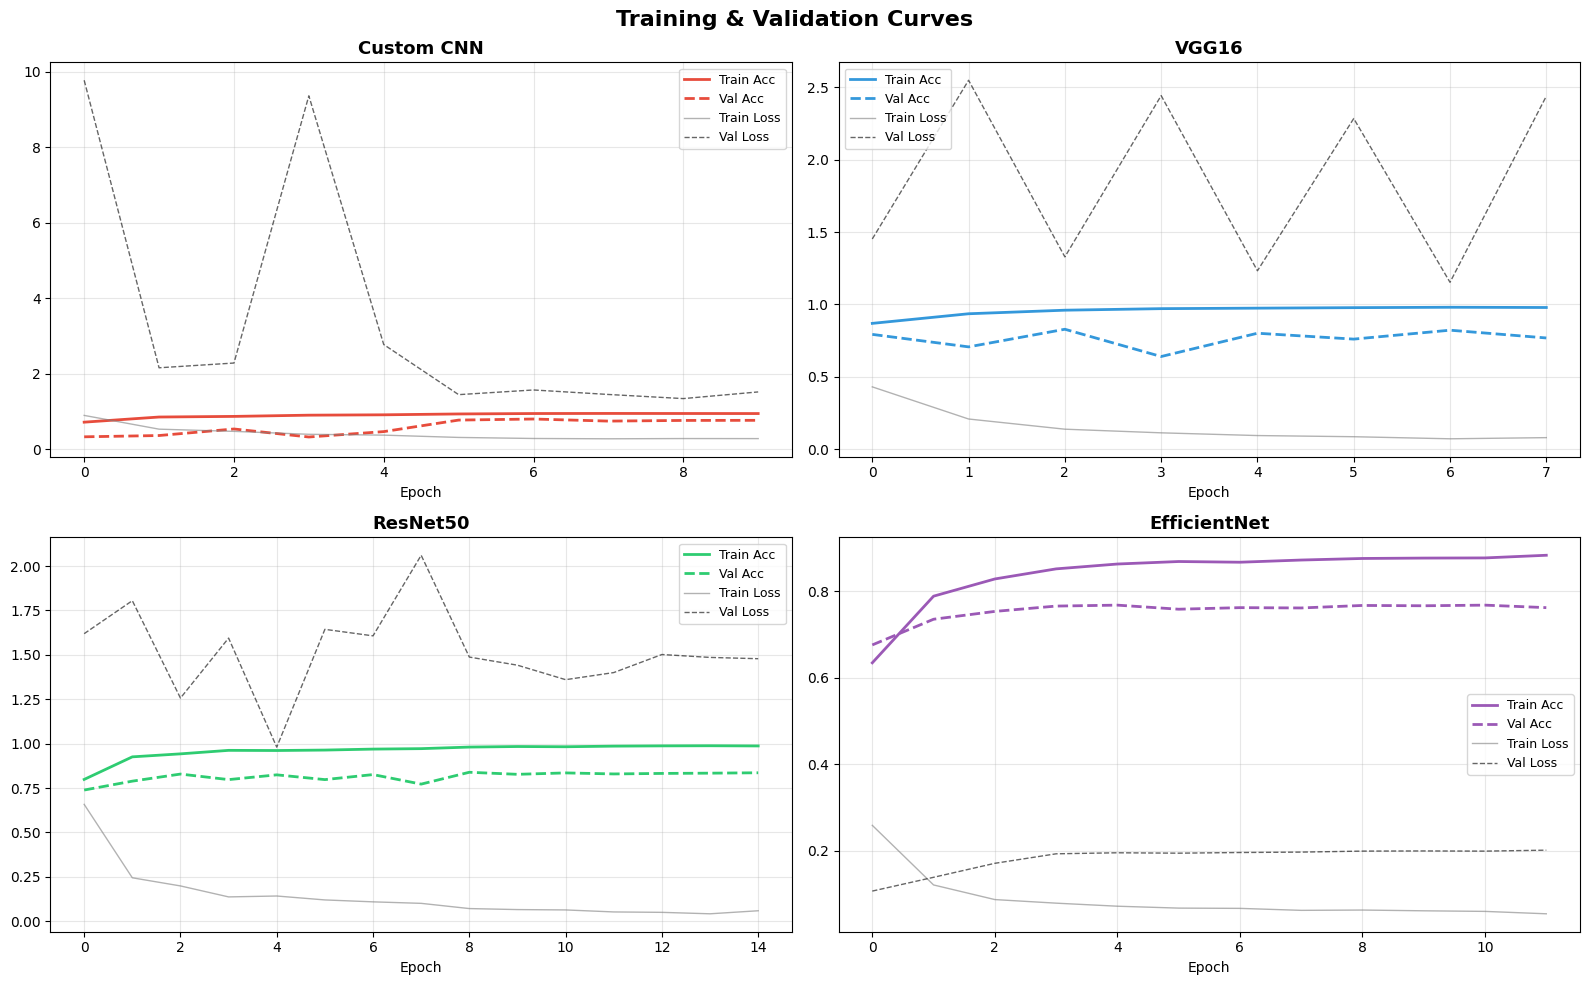

In [ ]:
histories = {
    'Custom CNN':   cnn_history,
    'VGG16':        vgg_history,
    'ResNet50':     resnet_history,
    'EfficientNet': efficientnet_history
}
hist_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, hist) in enumerate(histories.items()):
    ax = axes[idx]
    ax.plot(hist.history['accuracy'],     color=hist_colors[idx], linestyle='-',  linewidth=2, label='Train Acc')
    ax.plot(hist.history['val_accuracy'], color=hist_colors[idx], linestyle='--', linewidth=2, label='Val Acc')
    ax.plot(hist.history['loss'],         color='gray',           linestyle='-',  linewidth=1, label='Train Loss', alpha=0.6)
    ax.plot(hist.history['val_loss'],     color='black',          linestyle='--', linewidth=1, label='Val Loss',   alpha=0.6)
    ax.set_title(f'{name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()

# **Step 5: Evaluation**

Models are evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrices.

In [ ]:
models = {
    'Custom CNN':   (cnn_model,           cnn_val),
    'VGG16':        (vgg_model,           vgg_val),
    'ResNet50':     (resnet_model,        resnet_val),
    'EfficientNet': (efficientnet_model,  eff_val),
}

results = {}
for name, (model, val) in models.items():
    val.reset()
    loss, acc = model.evaluate(val, verbose=0)
    val.reset()
    preds = model.predict(val, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = val.classes
    report = classification_report(true_classes, pred_classes,
                                   target_names=CLASSES, output_dict=True)
    results[name] = {
        'accuracy':  round(acc * 100, 2),
        'loss':      round(loss, 4),
        'precision': round(report['weighted avg']['precision'] * 100, 2),
        'recall':    round(report['weighted avg']['recall'] * 100, 2),
        'f1':        round(report['weighted avg']['f1-score'] * 100, 2),
        'preds':     pred_classes,
        'trues':     true_classes
    }
    print(f"{name}: Acc={acc*100:.2f}%  Loss={loss:.4f}")

Custom CNN: Acc=80.64%  Loss=1.5755
VGG16: Acc=82.81%  Loss=1.3281
ResNet50: Acc=83.90%  Loss=1.4874
EfficientNet: Acc=76.79%  Loss=0.1947


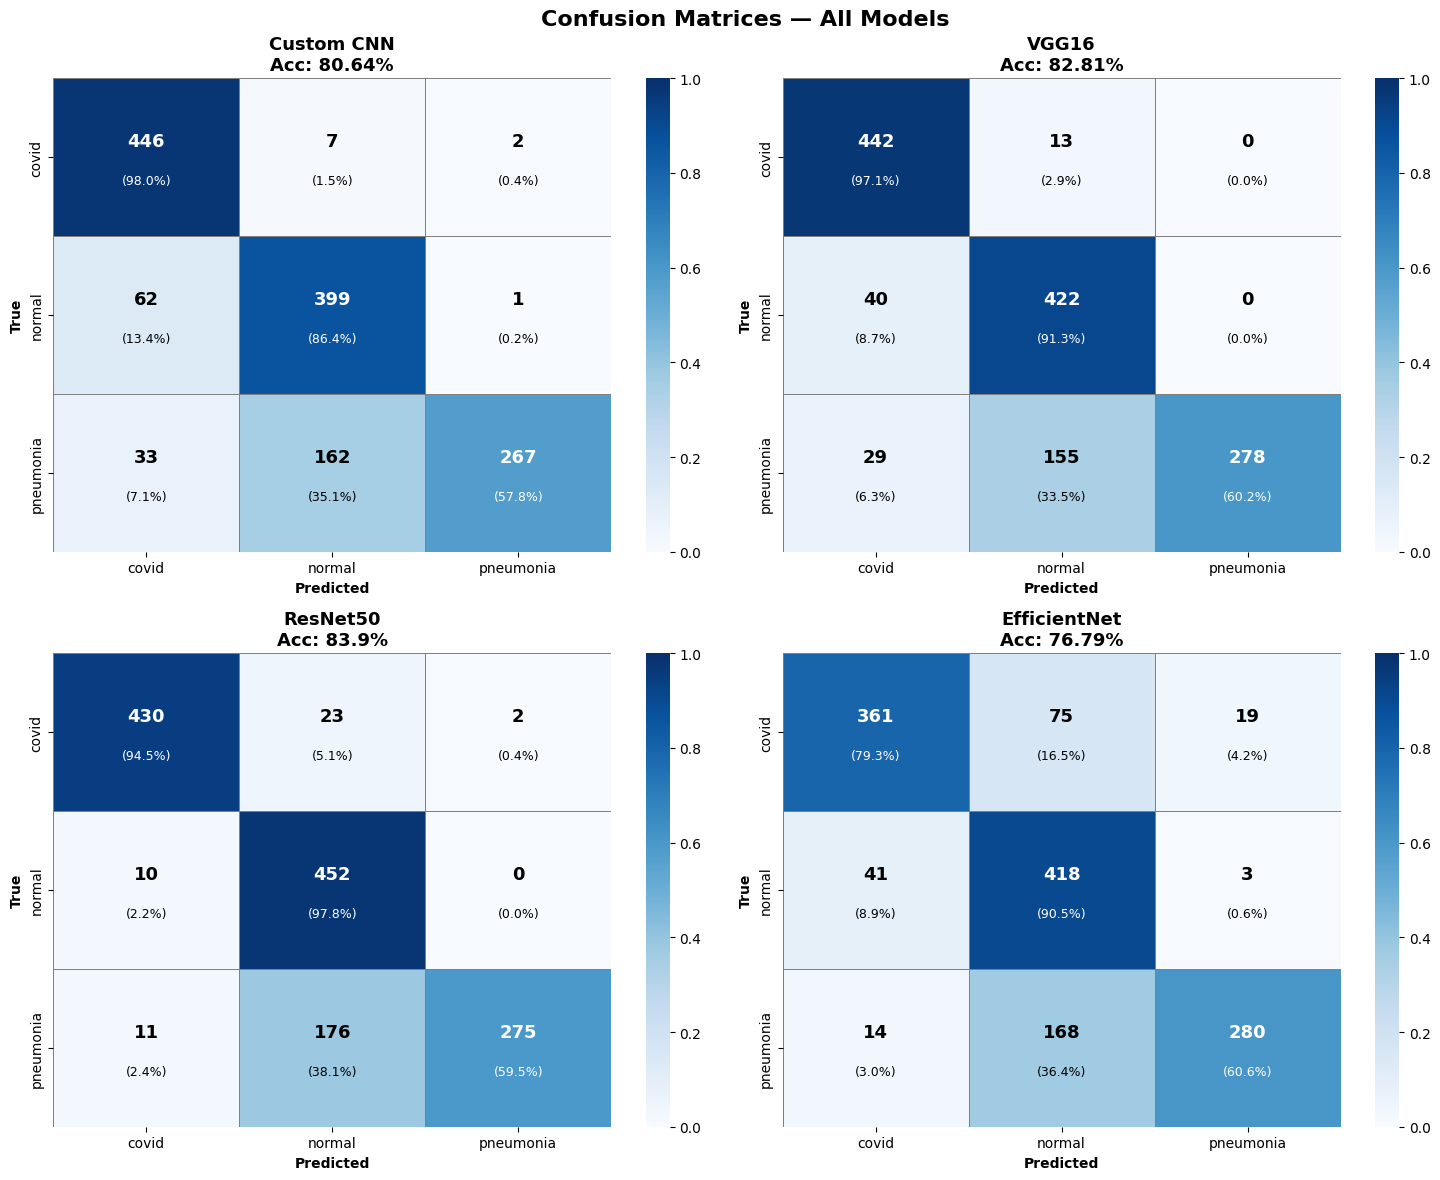

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    cm = confusion_matrix(res['trues'], res['preds'])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=False, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='gray', ax=ax, vmin=0, vmax=1)

    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j + 0.5, i + 0.4, f'{cm[i][j]}',
                    ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if cm_normalized[i][j] > 0.5 else 'black')
            ax.text(j + 0.5, i + 0.65, f'({cm_normalized[i][j]*100:.1f}%)',
                    ha='center', va='center', fontsize=9,
                    color='white' if cm_normalized[i][j] > 0.5 else 'black')

    ax.set_title(f'{name}\nAcc: {res["accuracy"]}%', fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True', fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()

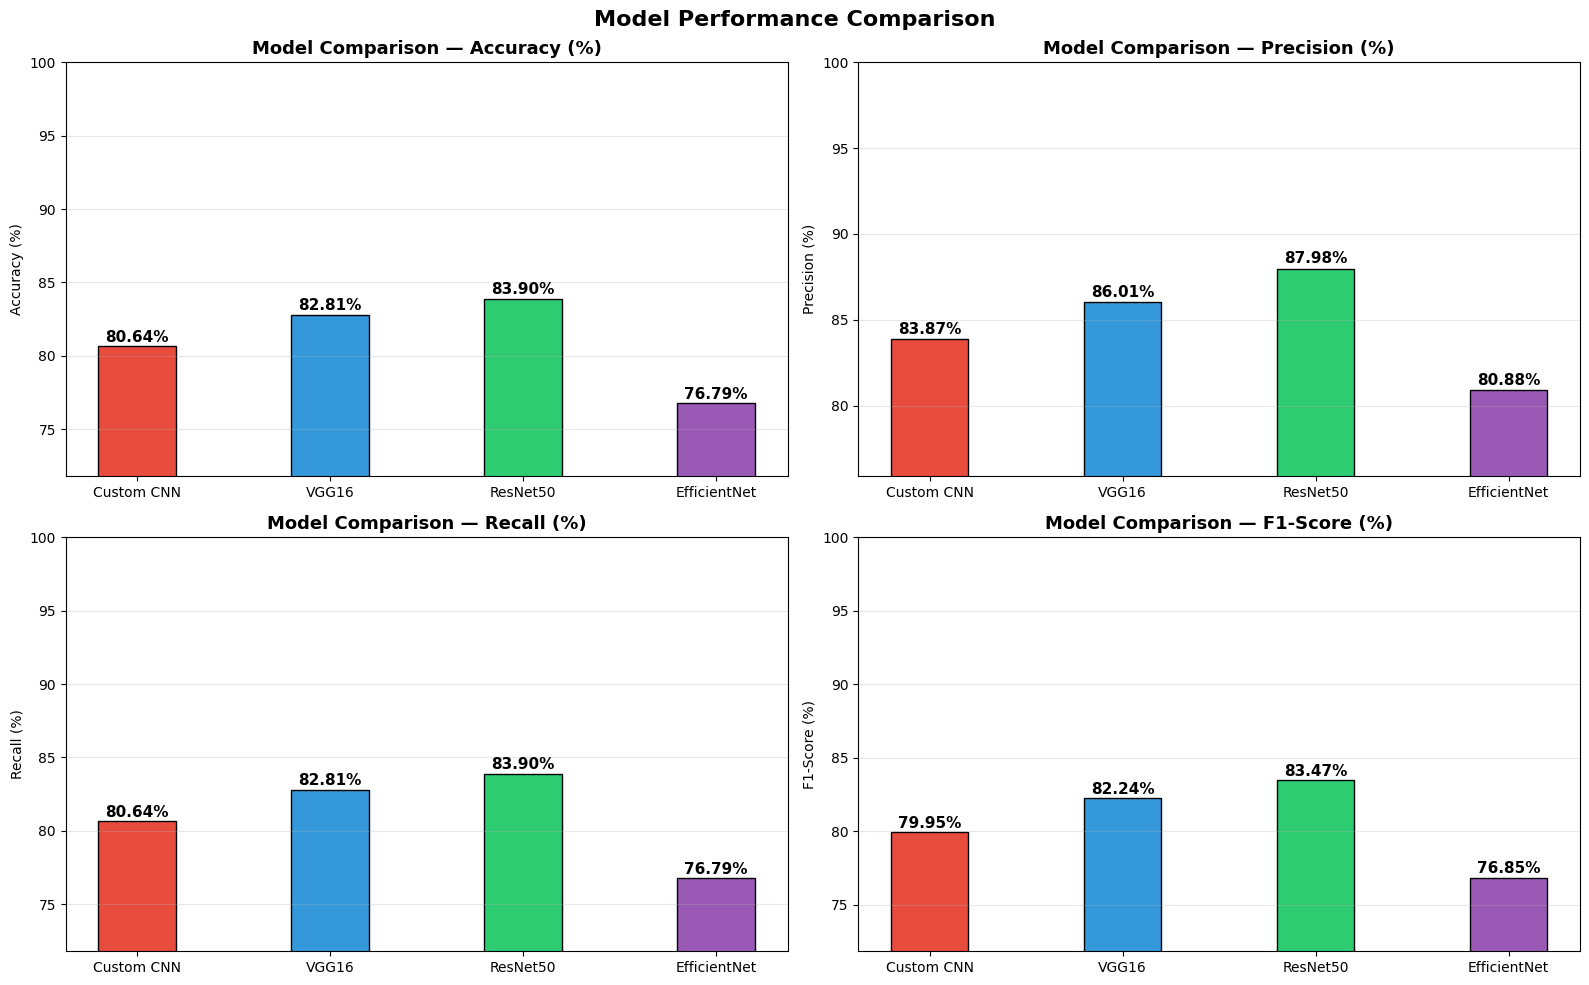

In [ ]:
df_results = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
hist_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 2][idx % 2]
    bars = ax.bar(df_results['Model'], df_results[metric].astype(float),
                  color=hist_colors, edgecolor='black', width=0.4)
    ax.set_title(f'Model Comparison — {label}', fontweight='bold', fontsize=13)
    ax.set_ylabel(label)
    ax.set_ylim([df_results[metric].astype(float).min() - 5, 100])
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

In [ ]:
df_display = df_results[['Model', 'accuracy', 'precision', 'recall', 'f1', 'loss']].copy()
df_display.columns = ['Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'Loss']
df_display = df_display.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print("=" * 65)
print(df_display.to_string(index=False))
print("=" * 65)

best_model_name = df_display.iloc[0]['Model']
best_model = models[best_model_name][0]
best_acc = df_display.iloc[0]['Accuracy (%)']

print(f"\n✅ Best Model: {best_model_name} with {best_acc}% Accuracy")

       Model Accuracy (%) Precision (%) Recall (%) F1-Score (%)    Loss
    ResNet50         83.9         87.98       83.9        83.47  1.4874
       VGG16        82.81         86.01      82.81        82.24  1.3281
  Custom CNN        80.64         83.87      80.64        79.95  1.5755
EfficientNet        76.79         80.88      76.79        76.85  0.1947

✅ Best Model: ResNet50 with 83.9% Accuracy


Classification Report — ResNet50
              precision    recall  f1-score   support

       covid       0.95      0.95      0.95       455
      normal       0.69      0.98      0.81       462
   pneumonia       0.99      0.60      0.74       462

    accuracy                           0.84      1379
   macro avg       0.88      0.84      0.84      1379
weighted avg       0.88      0.84      0.83      1379



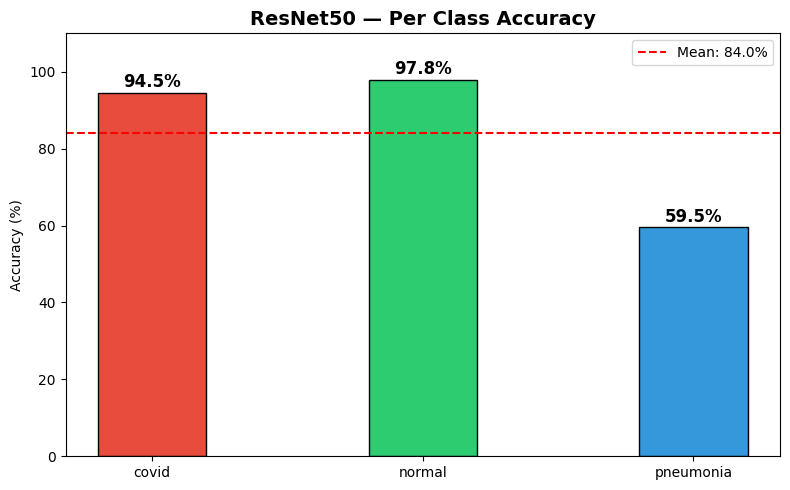

In [ ]:
best_val_gen = models[best_model_name][1]
best_val_gen.reset()
best_preds = best_model.predict(best_val_gen, verbose=0)
best_pred_classes = np.argmax(best_preds, axis=1)
true_classes = best_val_gen.classes

print(f"Classification Report — {best_model_name}")
print("=" * 60)
print(classification_report(true_classes, best_pred_classes, target_names=CLASSES))

cm_best = confusion_matrix(true_classes, best_pred_classes)
per_class_acc = cm_best.diagonal() / cm_best.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(CLASSES, per_class_acc, color=COLORS, edgecolor='black', width=0.4)
ax.set_title(f'{best_model_name} — Per Class Accuracy', fontweight='bold', fontsize=14)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 110])
ax.axhline(y=np.mean(per_class_acc), color='red', linestyle='--',
           label=f'Mean: {np.mean(per_class_acc):.1f}%')
ax.legend()
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('best_model_per_class.png', dpi=100)
plt.show()

In [ ]:
best_model.save('best_model_final.keras')
print(f"Saved: best_model_final.keras ({best_model_name})")

Saved: best_model_final.keras (ResNet50)


# **Step 6: Gradio Demo**

In [ ]:
best_model_loaded = tf.keras.models.load_model('best_model_final.keras')

# Determine which preprocess to use for the best model
preprocess_map = {
    'Custom CNN':   lambda img: img / 255.0,
    'VGG16':        vgg_preprocess,
    'ResNet50':     resnet_preprocess,
    'EfficientNet': eff_preprocess,
}
best_preprocess = preprocess_map[best_model_name]

def predict_xray(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32)
    img = best_preprocess(img)
    img = np.expand_dims(img, axis=0)
    preds = best_model_loaded.predict(img)[0]
    return {CLASSES[i]: float(preds[i]) for i in range(len(CLASSES))}

interface = gr.Interface(
    fn=predict_xray,
    inputs=gr.Image(type='numpy', label="Upload Chest X-Ray"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title=f"🫁 COVID-19 / Pneumonia / Normal Classifier",
    description=f"Best Model: {best_model_name} | Accuracy: {best_acc}% | Upload a chest X-ray image to classify.",
    theme=gr.themes.Soft()
)

interface.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa21db701691110b1b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion

This project successfully developed and compared four deep learning models for classifying chest X-ray images into COVID-19, Normal, and Pneumonia categories.

**Key fixes that improved performance:**
1. Fixed critical VGG16 indentation bug — classifier head was inside the `for` loop
2. Disabled `horizontal_flip` — X-rays should never be flipped
3. Each model uses its own correct preprocessing function
4. Fine-tuning enabled on last layers with appropriate low learning rates
5. BatchNorm frozen in ResNet50 and EfficientNet to prevent instability
6. More epochs with EarlyStopping to let models converge properly
7. Added L2 regularization to Custom CNN

## Limitations
- Limited dataset size
- No external clinical validation
- Performance may vary with different hospital datasets

## Future Work
- Use larger and more diverse datasets
- Explore DenseNet and Vision Transformer architectures
- Conduct clinical validation studies